Problem Statement:
2) Data Wrangling II
Create an “Academic performance” dataset of students and perform the following operations using Python.
1. Scan all variables for missing values and inconsistencies. If there are missing values and/or inconsistencies, use any of the suitable techniques to deal with them.
2. Scan all numeric variables for outliers. If there are outliers, use any of the suitable techniques to deal with them.
3. Apply data transformations on at least one of the variables. The purpose of this
transformation should be one of the following reasons: to change the scale for better
understanding of the variable, to convert a non-linear relation into a linear one, or to decrease the skewness and convert the distribution into a normal distribution.
Reason and document your approach properly.

In [2]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [3]:
student=pd.read_csv(r"C:\Users\Lenovo\Desktop\Data Science Practicals\Data_Science\02_Data Wrangling II\Students Performance.csv")

In [4]:
print(student.shape)

(399, 5)


In [5]:
student.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 399 entries, 0 to 398
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Math_Score       399 non-null    int64
 1   Reading_Score    399 non-null    int64
 2   Writing_Score    399 non-null    int64
 3   Placement_Score  399 non-null    int64
 4   Club_Join_Date   399 non-null    int64
dtypes: int64(5)
memory usage: 15.7 KB


In [6]:
student.head(10)

,Math_Score,Reading_Score,Writing_Score,Placement_Score,Club_Join_Date
0,65,86,67,78,2021
1,64,85,71,80,2019
2,76,77,77,84,2021
3,80,76,75,75,2021
4,63,91,62,90,2019
5,73,95,62,79,2020
6,72,82,76,79,2020
7,77,82,62,87,2021
8,74,90,60,100,2019
9,68,85,72,89,2019


In [7]:
student.isnull().sum()

Math_Score         0
Reading_Score      0
Writing_Score      0
Placement_Score    0
Club_Join_Date     0
dtype: int64

In [8]:
student.describe()

,Math_Score,Reading_Score,Writing_Score,Placement_Score,Club_Join_Date
count,399.000000,399.000000,399.000000,399.000000,399.000000
mean,79.182957,79.681704,79.167920,80.345865,2019.481203
std,11.871765,11.319323,12.039064,11.452356,1.115907
min,60.000000,60.000000,60.000000,60.000000,2018.000000
25%,69.000000,70.000000,68.000000,71.000000,2018.000000
50%,79.000000,80.000000,78.000000,80.000000,2019.000000
75%,90.000000,89.000000,90.000000,89.000000,2020.000000
max,100.000000,100.000000,100.000000,100.000000,2021.000000


In [9]:
new_student = student.dropna(axis = 0, how = 'any')
new_student

,Math_Score,Reading_Score,Writing_Score,Placement_Score,Club_Join_Date
0,65,86,67,78,2021
1,64,85,71,80,2019
2,76,77,77,84,2021
3,80,76,75,75,2021
4,63,91,62,90,2019
...,...,...,...,...,...
394,85,95,74,60,2020
395,67,87,96,93,2021
396,92,81,93,64,2021
397,100,64,97,88,2021


In [10]:
student.head()

,Math_Score,Reading_Score,Writing_Score,Placement_Score,Club_Join_Date
0,65,86,67,78,2021
1,64,85,71,80,2019
2,76,77,77,84,2021
3,80,76,75,75,2021
4,63,91,62,90,2019


In [11]:
new_student = student.dropna(axis = 0, how = 'all')
new_student

,Math_Score,Reading_Score,Writing_Score,Placement_Score,Club_Join_Date
0,65,86,67,78,2021
1,64,85,71,80,2019
2,76,77,77,84,2021
3,80,76,75,75,2021
4,63,91,62,90,2019
...,...,...,...,...,...
394,85,95,74,60,2020
395,67,87,96,93,2021
396,92,81,93,64,2021
397,100,64,97,88,2021


In [12]:
student.select_dtypes('int').apply(pd.Series.nunique,axis = 0)

Math_Score         41
Reading_Score      41
Writing_Score      41
Placement_Score    41
Club_Join_Date      4
dtype: int64

In [13]:
student["Math_Score"]=student["Math_Score"].astype('float')

In [14]:
student.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 399 entries, 0 to 398
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Math_Score       399 non-null    float64
 1   Reading_Score    399 non-null    int64  
 2   Writing_Score    399 non-null    int64  
 3   Placement_Score  399 non-null    int64  
 4   Club_Join_Date   399 non-null    int64  
dtypes: float64(1), int64(4)
memory usage: 15.7 KB


In [15]:
categorical_F = student.select_dtypes(float)
categorical_F.describe()

,Math_Score
count,399.000000
mean,79.182957
std,11.871765
min,60.000000
25%,69.000000
50%,79.000000
75%,90.000000
max,100.000000


In [16]:
student.isnull().sum()

Math_Score         0
Reading_Score      0
Writing_Score      0
Placement_Score    0
Club_Join_Date     0
dtype: int64

In [17]:
x = student["Placement_Score"].mode()
x

0    84
Name: Placement_Score, dtype: int64

In [18]:
student["Placement_Score"].value_counts()

Placement_Score
84     18
77     17
93     17
80     16
69     15
83     15
89     14
78     13
100    13
88     13
60     13
85     13
95     12
94     12
97     11
76     11
75     11
63     10
62     10
65     10
87      9
64      9
74      9
71      9
98      8
82      8
79      7
86      7
68      7
67      7
66      6
81      6
73      6
91      6
90      5
61      5
70      5
96      4
72      4
92      4
99      4
Name: count, dtype: int64

In [58]:
student["Placement_Score"] = student["Placement_Score"].fillna(student["Placement_Score"].mode()[0])

In [20]:
student["Writing_Score"].mean()

np.float64(79.16791979949875)

In [21]:
student["Writing_Score"]=student["Writing_Score"].replace(np.nan,student["Writing_Score"].mean())

In [22]:
student["Reading_Score"].median()

80.0

In [23]:
student["Reading_Score"]=student["Reading_Score"].replace(np.nan,student["Reading_Score"].median())

In [24]:
student["Math_Score"].mode()

0    75.0
Name: Math_Score, dtype: float64

In [25]:
student["Math_Score"]=student["Math_Score"].replace(np.nan,student["Math_Score"].mode()[0])

In [26]:
student.head(5)

,Math_Score,Reading_Score,Writing_Score,Placement_Score,Club_Join_Date
0,65.0,86,67,78,2021
1,64.0,85,71,80,2019
2,76.0,77,77,84,2021
3,80.0,76,75,75,2021
4,63.0,91,62,90,2019


In [27]:
student["Club_Join_Date"]=student["Club_Join_Date"].fillna(student["Club_Join_Date"].mean())

In [28]:
student.mean()

Math_Score           79.182957
Reading_Score        79.681704
Writing_Score        79.167920
Placement_Score      80.345865
Club_Join_Date     2019.481203
dtype: float64

In [29]:
student["Math_Score"].mean()

np.float64(79.1829573934837)

In [30]:
data=pd.read_csv(r"C:\Users\Lenovo\Desktop\Data Science Practicals\Data_Science\02_Data Wrangling II\Students Performance.csv")
data

,Math_Score,Reading_Score,Writing_Score,Placement_Score,Club_Join_Date
0,65,86,67,78,2021
1,64,85,71,80,2019
2,76,77,77,84,2021
3,80,76,75,75,2021
4,63,91,62,90,2019
...,...,...,...,...,...
394,85,95,74,60,2020
395,67,87,96,93,2021
396,92,81,93,64,2021
397,100,64,97,88,2021


In [31]:
data["Math_Score"]=data["Math_Score"].fillna(method='ffill')

In [32]:
data.head()

,Math_Score,Reading_Score,Writing_Score,Placement_Score,Club_Join_Date
0,65,86,67,78,2021
1,64,85,71,80,2019
2,76,77,77,84,2021
3,80,76,75,75,2021
4,63,91,62,90,2019


In [33]:
student.isnull().sum()

Math_Score         0
Reading_Score      0
Writing_Score      0
Placement_Score    0
Club_Join_Date     0
dtype: int64

In [34]:
student.head()

,Math_Score,Reading_Score,Writing_Score,Placement_Score,Club_Join_Date
0,65.0,86,67,78,2021
1,64.0,85,71,80,2019
2,76.0,77,77,84,2021
3,80.0,76,75,75,2021
4,63.0,91,62,90,2019


## OUTLIERS

In [35]:
import matplotlib.pyplot as plt

In [36]:
data = [37,40,42,37,32,49,190,50,37,37,34,36,34,-10,38,48,42,33,230,36,39,47,49,37,37,120,49,40,37,41,31,-25,37,36,33,48,45,47,48,46,44,38,41,37,47,42]

In [37]:
##Scatter Plot
z=range(len(data))
z

range(0, 46)

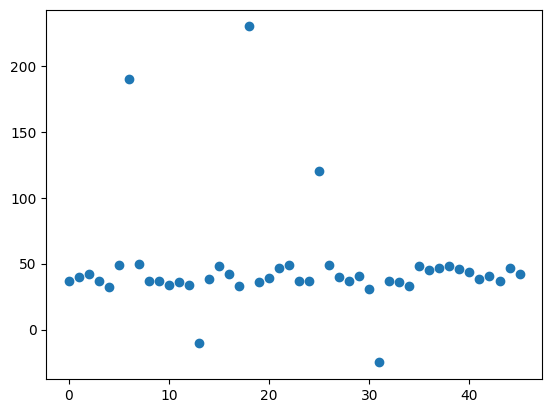

In [38]:
plt.scatter(z,y=data)
plt.show()

In [39]:
df = pd.DataFrame(data)
df

,0
0,37
1,40
2,42
3,37
4,32
5,49
6,190
7,50
8,37
9,37


In [40]:
index_names = df[df[0] >70].index
less_val = df[df[0] <20].index

In [41]:
index_names

Index([6, 18, 25], dtype='int64')

In [42]:
less_val

Index([13, 31], dtype='int64')

In [43]:
df.drop(index_names,inplace=True)
df.drop(less_val,inplace=True)

In [44]:
df

,0
0,37
1,40
2,42
3,37
4,32
5,49
7,50
8,37
9,37
10,34


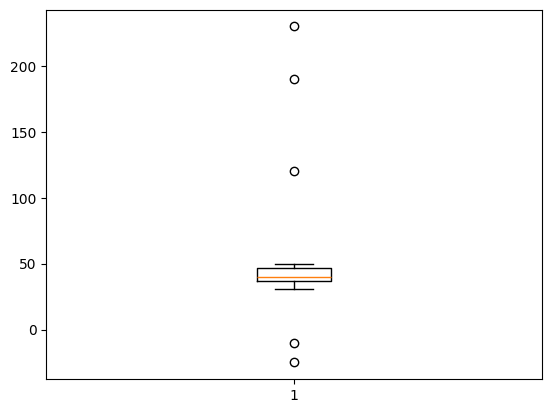

In [45]:
##Boxplot
plt.boxplot(x=data)
plt.show()

In [46]:
outliers = []
def detect_outliers(x):
    threshold = 3
    mean = np.mean(x)
    std = np.std(x)
    for i in x:
        z_score = (i-mean)/std
        if np.abs(z_score) > threshold:
            outliers.append(i)
    return outliers

In [47]:
my_outlier = detect_outliers(data)
my_outlier

[190, 230]

In [48]:
outliers = []
def detect_outliers(x):
    threshold = 1
    mean = np.mean(x)
    std = np.std(x)
    for i in x:
        z_score = (i-mean)/std
        if np.abs(z_score) > threshold:
            outliers.append(i)
    return outliers

In [49]:
my_outlier = detect_outliers(data)
my_outlier

[190, -10, 230, 120, -25]

Using IQR-INTER QUARTILE RANGE

STEPS:

1.SORT DATA

2.CALCULATE Q1 AND Q3

3.CALC IQR=Q3-Q1

4.CALC LOWER BOUND

5.CALC UPPER BOUND

In [50]:
#1.SORT DATA
data=sorted(data)
data

[-25,
 -10,
 31,
 32,
 33,
 33,
 34,
 34,
 36,
 36,
 36,
 37,
 37,
 37,
 37,
 37,
 37,
 37,
 37,
 37,
 38,
 38,
 39,
 40,
 40,
 41,
 41,
 42,
 42,
 42,
 44,
 45,
 46,
 47,
 47,
 47,
 48,
 48,
 48,
 49,
 49,
 49,
 50,
 120,
 190,
 230]

In [51]:
##calc q1,q3
q1,q3= np.percentile(data,[25,75])
print(q1,q3)

37.0 47.0


In [52]:
iqr = q3 - q1
iqr

np.float64(10.0)

In [53]:
##find lb and ub
lower_bound_value = q1 - (1.5*iqr)
upper_bound_value = q3 + (1.5*iqr)
print(lower_bound_value,upper_bound_value)

22.0 62.0


In [54]:
df = pd.DataFrame(data)
df

,0
0,-25
1,-10
2,31
3,32
4,33
5,33
6,34
7,34
8,36
9,36


In [55]:
df =  df.rename(columns={0:"samples"})
df

,samples
0,-25
1,-10
2,31
3,32
4,33
5,33
6,34
7,34
8,36
9,36


In [56]:
df [df['samples']<lower_bound_value]

,samples
0,-25
1,-10


In [57]:
df [df['samples']<upper_bound_value]

,samples
0,-25
1,-10
2,31
3,32
4,33
5,33
6,34
7,34
8,36
9,36
